# LLM Fine-Tuning Assignment — Lightning AI (L40S / A100)
**Model:** Mistral-7B-v0.1 &nbsp;|&nbsp; **Dataset:** Dolly-15k &nbsp;|&nbsp; **Method:** QLoRA (4-bit)

**Setup before running:**
1. Studio → Switch GPU → **L40S** (recommended) or A100
2. Wait for the studio to restart with the GPU attached
3. Open this notebook → Run all cells top to bottom

**Total time on L40S:** ~30–40 minutes  
**Total time on A100:** ~25–30 minutes

Lightning AI provides a clean Python environment with no version conflicts —
unlike Colab, the installs in Cell 1 just work without surprises.


## Cell 0 — Verify GPU

In [1]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout)

import torch
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM           : {vram:.1f} GB")

# bf16 support — L40S and A100 both have it, T4 does not
print(f"BF16 supported : {torch.cuda.is_bf16_supported()}")

Thu May  7 07:23:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    Off |   00000000:34:00.0 Off |                    0 |
| N/A   44C    P8             35W /  350W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 1 — Install packages
Lightning AI ships a recent CUDA + PyTorch, so we just install the ML stack on top.
No conflicts, no torch reinstallation needed.


In [17]:
# ── Cell A: Install plotting library ──────────────────────────────────────────
import subprocess
subprocess.run("pip install -q matplotlib seaborn", shell=True)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
print("Plotting libraries ready.")

Plotting libraries ready.


In [2]:
import subprocess

def sh(cmd):
    subprocess.run(cmd, shell=True)

print("Installing packages...")
sh("pip install -q --upgrade pip")
sh("pip install -q "
   "transformers==4.46.3 "
   "tokenizers==0.20.3 "
   "huggingface_hub==0.26.5 "
   "accelerate==1.1.1 "
   "peft==0.13.2 "
   "trl==0.12.0 "
   "bitsandbytes==0.45.0 "
   "datasets==3.1.0 "
   "evaluate==0.4.3 "
   "rouge_score "
   "sacrebleu "
   "sentencepiece "
   "protobuf")
print("Done.")

Installing packages...
Done.


In [3]:
import subprocess

# Install bitsandbytes 0.46.1+ which has cu128 support
subprocess.run("pip uninstall -y bitsandbytes", shell=True)
subprocess.run("pip install -q bitsandbytes==0.46.1", shell=True)

# Verify
import sys
for mod in list(sys.modules.keys()):
    if 'bitsandbytes' in mod:
        del sys.modules[mod]

import bitsandbytes as bnb
print(f"bitsandbytes: {bnb.__version__}")

# Functional test — must work without errors
test = bnb.nn.Linear4bit(64, 64, bias=False, quant_type='nf4')
print("4-bit ops: OK")

from transformers.utils import is_bitsandbytes_available
print(f"transformers detects bnb: {is_bitsandbytes_available()}")

Found existing installation: bitsandbytes 0.45.0
Uninstalling bitsandbytes-0.45.0:
  Successfully uninstalled bitsandbytes-0.45.0
bitsandbytes: 0.46.1
4-bit ops: OK
transformers detects bnb: True


## Cell 2 — Verify environment
After Cell 1 finishes, run this — everything should print "OK".  
**No restart needed on Lightning AI** — pip installs are picked up immediately.


In [4]:
import sys
print(f"Python: {sys.version.split()[0]}")
print()

errors = []

import torch
print(f"torch          : {torch.__version__}")
print(f"CUDA           : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE'}")

try:
    import bitsandbytes as bnb
    print(f"bitsandbytes   : {bnb.__version__}")
    test = bnb.nn.Linear4bit(64, 64, bias=False, quant_type='nf4')
    print(f"  4-bit ops    : OK")
except Exception as e:
    errors.append(f"bitsandbytes: {e}")

try:
    import transformers
    print(f"transformers   : {transformers.__version__}")
    from transformers.utils import is_bitsandbytes_available
    if is_bitsandbytes_available():
        print(f"  bnb detected : OK")
    else:
        errors.append("transformers cannot detect bitsandbytes")
except Exception as e:
    errors.append(f"transformers: {e}")

for pkg, expected in [('peft','0.13'), ('trl','0.12'), ('accelerate','1.1'),
                       ('datasets','3.1'), ('evaluate','0.4')]:
    try:
        m = __import__(pkg)
        print(f"{pkg:<15}: {m.__version__}")
    except Exception as e:
        errors.append(f"{pkg}: {e}")

print()
if errors:
    print("ERRORS:")
    for e in errors:
        print(f"  X {e}")
else:
    print("All checks passed. Proceed to Cell 3.")

Python: 3.12.11

torch          : 2.8.0+cu128
CUDA           : NVIDIA L40S
bitsandbytes   : 0.46.1
  4-bit ops    : OK
transformers   : 4.46.3
  bnb detected : OK
peft           : 0.13.2
trl            : 0.12.0
accelerate     : 1.1.1
datasets       : 3.1.0
evaluate       : 0.4.3

All checks passed. Proceed to Cell 3.


## Cell 3 — HuggingFace login (optional for Mistral)
Mistral-7B is public — login is optional. If you want to use a gated model later
(LLaMA-2, etc.), set HF_TOKEN as an environment variable in Lightning AI's
Studio Settings → Environment Variables.


In [5]:
import os
from huggingface_hub import login

token = os.environ.get('HF_TOKEN')
if token:
    login(token=token, add_to_git_credential=False)
    print("Logged in via HF_TOKEN env var.")
else:
    print("No HF_TOKEN set — proceeding without auth (fine for Mistral).")

No HF_TOKEN set — proceeding without auth (fine for Mistral).


## Cell 4 — Configuration

In [6]:
import torch

MODEL_ID     = "mistralai/Mistral-7B-v0.1"
OUTPUT_DIR   = "./mistral-dolly-lora"

# ── Better hyperparameters for L40S/A100 (more VRAM than T4) ──────────────────
MAX_SEQ_LEN  = 1024     # longer than T4 — we have VRAM headroom
NUM_EPOCHS   = 3
BATCH_SIZE   = 8        # larger batch on big GPU
GRAD_ACCUM   = 2        # effective batch = 16
LR           = 2e-4
WARMUP_RATIO = 0.03

LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

TEST_SPLIT   = 0.05
EVAL_SAMPLES = 200      # more eval examples — fast on these GPUs
SEED         = 42

# bf16 (better than fp16) on L40S/A100 — auto-detect
USE_BF16     = torch.cuda.is_bf16_supported()
print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Precision      : {'bfloat16' if USE_BF16 else 'float16'}")
print(f"Effective batch: {BATCH_SIZE * GRAD_ACCUM}")
print(f"Max seq len    : {MAX_SEQ_LEN}")
print(f"LoRA r/alpha   : {LORA_R}/{LORA_ALPHA}")

GPU            : NVIDIA L40S
VRAM           : 47.7 GB
Precision      : bfloat16
Effective batch: 16
Max seq len    : 1024
LoRA r/alpha   : 16/32


## Cell 5 — Load Mistral-7B in 4-bit QLoRA

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# bf16 compute on L40S/A100 — better numerical stability than fp16
compute_dtype = torch.bfloat16 if USE_BF16 else torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Downloading and loading {MODEL_ID} in 4-bit...")
print(f"~14 GB download. On Lightning AI: ~1-2 min.")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype,
)
base_model.config.use_cache      = False
base_model.config.pretraining_tp = 1

params = sum(p.numel() for p in base_model.parameters()) / 1e9
vram   = torch.cuda.memory_allocated() / 1e9
total  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\nLoaded: {params:.2f}B parameters")
print(f"VRAM   : {vram:.2f} / {total:.0f} GB ({100*vram/total:.0f}%)")

Loading tokenizer...
~14 GB download. On Lightning AI: ~1-2 min.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Loaded: 3.75B parameters
VRAM   : 4.13 / 48 GB (9%)


## Cell 6 — Load and format Dolly-15k

In [9]:
from datasets import load_dataset

print("Downloading Dolly-15k...")
raw = load_dataset("databricks/databricks-dolly-15k", split="train")
print(f"Loaded {len(raw)} examples. Columns: {raw.column_names}")

def format_example(ex):
    ctx = ex.get("context", "").strip()
    ctx_block = f"### Input:\n{ctx}\n" if ctx else ""
    return {"text": (
        f"### Instruction:\n{ex['instruction']}\n"
        f"{ctx_block}"
        f"### Response:\n{ex['response']}"
    )}

dataset  = raw.map(format_example, remove_columns=raw.column_names)
split    = dataset.train_test_split(test_size=TEST_SPLIT, seed=SEED)
train_ds = split["train"]
test_ds  = split["test"]

print(f"Train: {len(train_ds):,}  |  Test: {len(test_ds):,}")
print(f"\nFormatted sample:")
print(train_ds[0]["text"][:350])

Loaded 15011 examples. Columns: ['instruction', 'context', 'response', 'category']
Train: 14,260  |  Test: 751

Formatted sample:
### Instruction:
Who were the "Big Four" of Grunge?
### Response:
Alice in Chains, Soundgarden, Nirvana, and Pearl Jam.


## Cell 7 — Attach LoRA adapters

In [10]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

base_model = prepare_model_for_kbit_training(
    base_model, use_gradient_checkpointing=True
)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(base_model, lora_config)

total     = sum(p.numel() for p in peft_model.parameters())
trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
print(f"Total      : {total/1e9:.3f}B params")
print(f"Trainable  : {trainable/1e6:.2f}M ({100*trainable/total:.3f}%)")
print(f"Frozen base: {(total-trainable)/1e9:.3f}B")

Total      : 3.766B params
Trainable  : 13.63M (0.362%)
Frozen base: 3.752B


## Cell 8 — Fine-tune
**Estimated time:**
- L40S : ~35 minutes
- A100 : ~25 minutes

Watch loss decrease from ~2.0 toward ~1.0.


In [11]:
import os
from trl import SFTTrainer, SFTConfig

os.makedirs(OUTPUT_DIR, exist_ok=True)

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    optim="paged_adamw_8bit",
    learning_rate=LR,
    lr_scheduler_type="cosine",
    warmup_ratio=WARMUP_RATIO,

    # bf16 on L40S/A100 (better than fp16)
    bf16=USE_BF16,
    fp16=not USE_BF16,

    logging_steps=25,
    logging_first_step=True,
    save_strategy="epoch",
    eval_strategy="no",
    report_to="none",
    dataloader_num_workers=2,
    group_by_length=True,
    seed=SEED,

    # SFTConfig-specific
    max_seq_length=MAX_SEQ_LEN,
    packing=True,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=peft_model,
    train_dataset=train_ds,
    peft_config=lora_config,
    tokenizer=tokenizer,
    args=training_args,
)

steps = len(trainer.get_train_dataloader())
print(f"Steps/epoch  : {steps}")
print(f"Total steps  : {steps * NUM_EPOCHS}")
print(f"Effective BS : {BATCH_SIZE * GRAD_ACCUM}")
print(f"Precision    : {'bf16' if USE_BF16 else 'fp16'}")
print(f"\nStarting training...")

result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nDone!")
print(f"Runtime    : {result.metrics['train_runtime']/60:.1f} min")
print(f"Final loss : {result.metrics['train_loss']:.4f}")
print(f"Throughput : {result.metrics['train_samples_per_second']:.1f} samples/sec")

Steps/epoch  : 364
Total steps  : 1092
Effective BS : 16
Precision    : bf16

Starting training...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,1.574500
25,1.550200
50,1.450600
75,1.437000
100,1.445900
125,1.414500
150,1.456600
175,1.450200
200,1.363200
225,1.335500


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



Done!
Runtime    : 80.0 min
Final loss : 1.3456
Throughput : 1.8 samples/sec


## Cell 9 — Reload base model and load fine-tuned adapter

In [12]:
import gc
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# Free training memory
del peft_model, trainer
gc.collect()
torch.cuda.empty_cache()

compute_dtype = torch.bfloat16 if USE_BF16 else torch.float16
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
)

# ── Base model (clean, for comparison) ────────────────────────────────────────
print("Loading clean base model for comparison...")
base_compare = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype,
)
base_compare.eval()

# ── Fine-tuned model (with LoRA adapter attached) ─────────────────────────────
print("Loading fine-tuned model...")
ft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype,
)
ft_model = PeftModel.from_pretrained(ft_model, OUTPUT_DIR)
ft_model.eval()

print(f"\nVRAM with both models: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading clean base model for comparison...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading fine-tuned model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


VRAM with both models: 13.03 GB


## Cell 10 — Generation helper

In [13]:
import torch

@torch.inference_mode()
def generate(model, instruction, context="", max_new_tokens=200):
    ctx_block = f"### Input:\n{context.strip()}\n" if context.strip() else ""
    prompt = (
        f"### Instruction:\n{instruction}\n"
        f"{ctx_block}"
        f"### Response:\n"
    )
    inputs  = tokenizer(prompt, return_tensors="pt").to(model.device)
    n_input = inputs["input_ids"].shape[-1]
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0][n_input:], skip_special_tokens=True).strip()

print("generate() ready.")

generate() ready.


## Cell 11 — Task 3: Base vs Fine-tuned comparison

In [14]:
prompts = [
    {"label": "Explanation",
     "instruction": "Explain the water cycle in simple terms for a 10-year-old.",
     "context": ""},
    {"label": "Code generation",
     "instruction": "Write a Python function that checks whether a string is a palindrome.",
     "context": ""},
    {"label": "Summarisation",
     "instruction": "Summarise the following passage in exactly two sentences.",
     "context": ("The mitochondria are membrane-bound organelles found in the cytoplasm of "
                 "eukaryotic cells. They generate most of the cell's supply of ATP. "
                 "They are also involved in signalling, differentiation, and cell death.")},
    {"label": "Information retrieval",
     "instruction": "List three major causes of the First World War.",
     "context": ""},
    {"label": "Style transfer",
     "instruction": "Rewrite the following sentence in formal English.",
     "context": "gonna grab some food real quick before we head out"},
]

for i, p in enumerate(prompts, 1):
    print(f"\n{'='*68}")
    print(f"[{i}/5]  {p['label'].upper()}")
    print(f"Instruction: {p['instruction']}")
    if p["context"]:
        print(f"Context    : {p['context'][:80]}...")
    print("-" * 68)
    print(f"BASE MODEL:")
    print(generate(base_compare, p["instruction"], p["context"]))
    print(f"\nFINE-TUNED:")
    print(generate(ft_model, p["instruction"], p["context"]))
print(f"\n{'='*68}")


[1/5]  EXPLANATION
Instruction: Explain the water cycle in simple terms for a 10-year-old.
--------------------------------------------------------------------
BASE MODEL:
Water is an essential part of life, and it's all around us! It comes from the sky as rain or snow, collects in lakes and rivers, evaporates into the air, condenses to form clouds, then rains back down again. This is called the water cycle. Water can be used by plants and animals for food, drink, and to cool off. We need water for our bodies too! It helps us stay healthy and strong. When we get thirsty, we can drink some water to quench our thirst. Without water, nothing would grow, nothing would live, and everything would die!
#### The water cycle happens over and over again.
![The water cycle](https://raw.githubusercontent.com/Darshan-Choudhary29/watercycle_explanation/main/images/the_water_cycle.png)


### Explanation of each step in

FINE-TUNED:
Water is very important to humans and other animals because it helps

## Cell 12 — Task 4: BLEU & ROUGE evaluation

In [15]:
import evaluate
from tqdm import tqdm

bleu_metric  = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

def evaluate_model(model, dataset, n=EVAL_SAMPLES, label=""):
    preds, refs = [], []
    for ex in tqdm(dataset.select(range(min(n, len(dataset)))),
                   desc=f"{label}", ncols=70):
        parts = ex["text"].split("### Response:\n")
        ref   = parts[-1].strip() if len(parts) > 1 else ""
        pre   = parts[0]
        instr = pre.split("### Instruction:\n")[-1].split("### Input:\n")[0].strip()
        ctx   = pre.split("### Input:\n")[-1].strip() if "### Input:\n" in pre else ""
        preds.append(generate(model, instr, ctx, max_new_tokens=150))
        refs.append(ref)
    bleu  = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])
    rouge = rouge_metric.compute(predictions=preds, references=refs)
    return bleu, rouge, preds, refs

print(f"Evaluating {EVAL_SAMPLES} held-out examples on each model...")
base_bleu, base_rouge, base_preds, refs = evaluate_model(base_compare, test_ds, label="Base       ")
ft_bleu,   ft_rouge,   ft_preds,   _   = evaluate_model(ft_model,    test_ds, label="Fine-tuned ")

metrics = {
    "BLEU-1" : (base_bleu["precisions"][0], ft_bleu["precisions"][0]),
    "BLEU-2" : (base_bleu["precisions"][1], ft_bleu["precisions"][1]),
    "BLEU-4" : (base_bleu["bleu"],           ft_bleu["bleu"]),
    "ROUGE-1": (base_rouge["rouge1"],         ft_rouge["rouge1"]),
    "ROUGE-2": (base_rouge["rouge2"],         ft_rouge["rouge2"]),
    "ROUGE-L": (base_rouge["rougeL"],         ft_rouge["rougeL"]),
}

print("\n" + "=" * 60)
print(f"{'Metric':<12} {'Base':>10} {'Fine-Tuned':>11} {'Change':>10}")
print("-" * 60)
for name, (b, ft) in metrics.items():
    delta = ((ft - b) / (b + 1e-9)) * 100
    sign  = "+" if delta >= 0 else "-"
    print(f"{name:<12} {b:>10.4f} {ft:>11.4f} {sign}{abs(delta):>8.1f}%")
print("=" * 60)

Evaluating 200 held-out examples on each model...


Fine-tuned : 100%|██████████████████| 200/200 [13:56<00:00,  4.18s/it]



Metric             Base  Fine-Tuned     Change
------------------------------------------------------------
BLEU-1           0.1769      0.4279 +   141.9%
BLEU-2           0.0467      0.1760 +   277.4%
BLEU-4           0.0381      0.0877 +   130.3%
ROUGE-1          0.2122      0.4056 +    91.1%
ROUGE-2          0.0686      0.2084 +   203.6%
ROUGE-L          0.1429      0.3329 +   133.0%


## Cell 13 — Save and download results

In [16]:
import json, datetime, shutil

results = {
    "timestamp"  : datetime.datetime.now().isoformat(),
    "model"      : MODEL_ID,
    "dataset"    : "databricks-dolly-15k",
    "platform"   : "Lightning AI",
    "gpu"        : torch.cuda.get_device_name(0),
    "precision"  : "bfloat16" if USE_BF16 else "float16",
    "lora_config": {"r": LORA_R, "alpha": LORA_ALPHA, "dropout": LORA_DROPOUT,
                    "scale": LORA_ALPHA/LORA_R,
                    "targets": ["q_proj","k_proj","v_proj","o_proj"]},
    "training"   : {"epochs": NUM_EPOCHS, "lr": LR,
                    "effective_batch": BATCH_SIZE * GRAD_ACCUM,
                    "max_seq_len": MAX_SEQ_LEN},
    "metrics"    : {k: {"base": round(b,4), "finetuned": round(ft,4),
                        "improvement_pct": round(((ft-b)/(b+1e-9))*100, 1)}
                    for k,(b,ft) in metrics.items()},
    "samples"    : [{"reference": refs[i][:120], "base": base_preds[i],
                     "finetuned": ft_preds[i]}
                    for i in range(min(5, len(refs)))],
}

# ── Save to current directory (Lightning AI persists this) ────────────────────
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

shutil.make_archive("lora_adapter_mistral_dolly", "zip", OUTPUT_DIR)

print("Files saved in current directory:")
print("  evaluation_results.json")
print("  lora_adapter_mistral_dolly.zip")
print()
print("Right-click them in the Lightning file browser → Download")
print()
print("Metrics summary:")
print(json.dumps(results["metrics"], indent=2))

Files saved in current directory:
  evaluation_results.json
  lora_adapter_mistral_dolly.zip

Right-click them in the Lightning file browser → Download

Metrics summary:
{
  "BLEU-1": {
    "base": 0.1769,
    "finetuned": 0.4279,
    "improvement_pct": 141.9
  },
  "BLEU-2": {
    "base": 0.0467,
    "finetuned": 0.176,
    "improvement_pct": 277.4
  },
  "BLEU-4": {
    "base": 0.0381,
    "finetuned": 0.0877,
    "improvement_pct": 130.3
  },
  "ROUGE-1": {
    "base": 0.2122,
    "finetuned": 0.4056,
    "improvement_pct": 91.1
  },
  "ROUGE-2": {
    "base": 0.0686,
    "finetuned": 0.2084,
    "improvement_pct": 203.6
  },
  "ROUGE-L": {
    "base": 0.1429,
    "finetuned": 0.3329,
    "improvement_pct": 133.0
  }
}


Plots

Reading training history from: ./mistral-dolly-lora/checkpoint-546/trainer_state.json
Loaded 22 training log entries
Initial loss: 1.5745
Final loss  : 1.2042


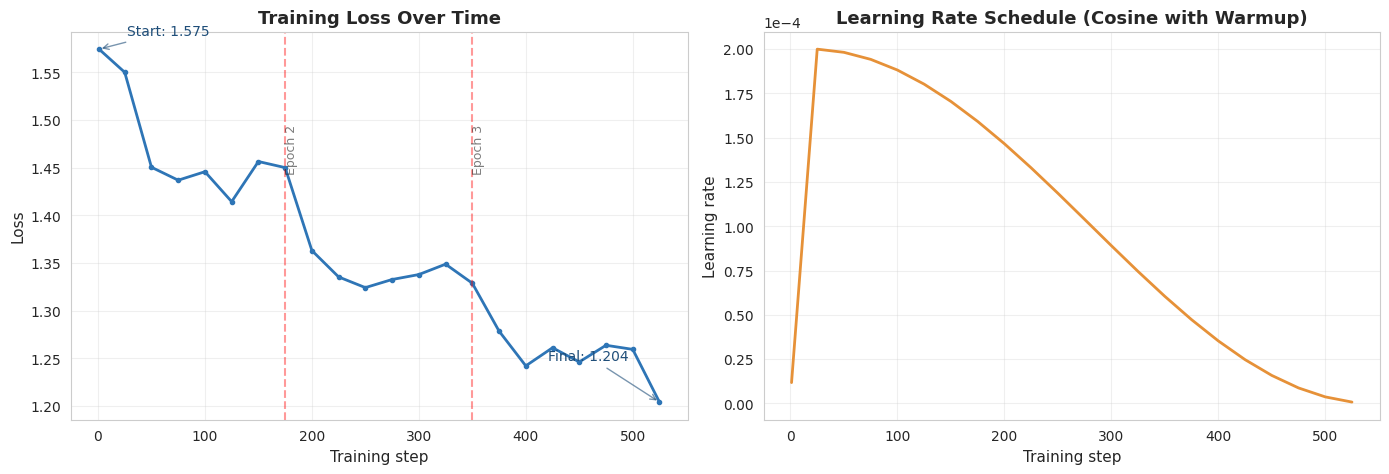


Loss reduction: 1.575 → 1.204  (23.5% decrease)


In [19]:
# ── Cell B (fixed): Training loss curve from saved trainer state ─────────────
import json
import os
import glob

# Find the most recent trainer_state.json from the saved checkpoints
checkpoint_dirs = sorted(glob.glob(f"{OUTPUT_DIR}/checkpoint-*"))
if checkpoint_dirs:
    state_path = os.path.join(checkpoint_dirs[-1], "trainer_state.json")
else:
    state_path = os.path.join(OUTPUT_DIR, "trainer_state.json")

print(f"Reading training history from: {state_path}")

with open(state_path, "r") as f:
    state = json.load(f)

log_history = state["log_history"]

train_steps    = [e['step']          for e in log_history if 'loss' in e]
train_loss     = [e['loss']          for e in log_history if 'loss' in e]
learning_rates = [e['learning_rate'] for e in log_history if 'learning_rate' in e]
lr_steps       = [e['step']          for e in log_history if 'learning_rate' in e]

print(f"Loaded {len(train_steps)} training log entries")
print(f"Initial loss: {train_loss[0]:.4f}")
print(f"Final loss  : {train_loss[-1]:.4f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_steps, train_loss, color='#2E75B6', linewidth=2, marker='o', markersize=3)
ax1.set_xlabel('Training step', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Training Loss Over Time', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Mark epoch boundaries
total_steps = train_steps[-1]
for epoch in range(1, NUM_EPOCHS):
    boundary = total_steps * epoch / NUM_EPOCHS
    ax1.axvline(boundary, color='red', linestyle='--', alpha=0.4)
    ax1.text(boundary, max(train_loss)*0.95, f'Epoch {epoch+1}',
             rotation=90, fontsize=9, alpha=0.6, va='top')

# Annotate first and last loss
ax1.annotate(f'Start: {train_loss[0]:.3f}',
             xy=(train_steps[0], train_loss[0]),
             xytext=(20, 10), textcoords='offset points',
             fontsize=10, color='#1F4E79',
             arrowprops=dict(arrowstyle='->', color='#1F4E79', alpha=0.6))
ax1.annotate(f'Final: {train_loss[-1]:.3f}',
             xy=(train_steps[-1], train_loss[-1]),
             xytext=(-80, 30), textcoords='offset points',
             fontsize=10, color='#1F4E79',
             arrowprops=dict(arrowstyle='->', color='#1F4E79', alpha=0.6))

# Learning rate schedule
ax2.plot(lr_steps, learning_rates, color='#E69138', linewidth=2)
ax2.set_xlabel('Training step', fontsize=11)
ax2.set_ylabel('Learning rate', fontsize=11)
ax2.set_title('Learning Rate Schedule (Cosine with Warmup)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

reduction = 100 * (train_loss[0] - train_loss[-1]) / train_loss[0]
print(f"\nLoss reduction: {train_loss[0]:.3f} → {train_loss[-1]:.3f}  ({reduction:.1f}% decrease)")

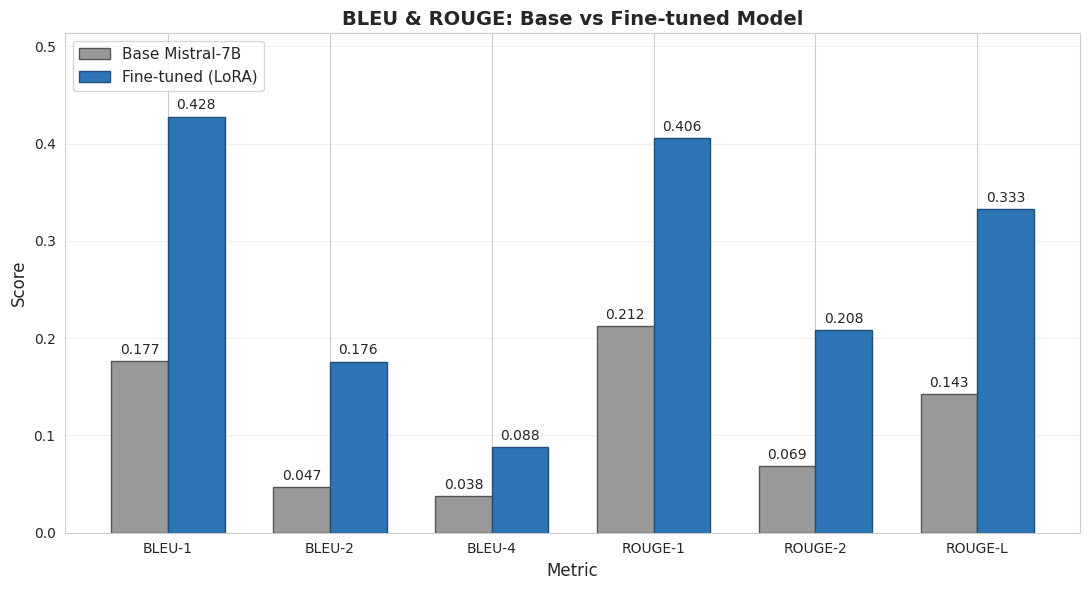

In [20]:
# ── Cell C: BLEU & ROUGE comparison bar chart ─────────────────────────────────
# Run this AFTER Cell 12 (the evaluation) so `metrics` exists

metric_names = list(metrics.keys())
base_scores  = [metrics[m][0] for m in metric_names]
ft_scores    = [metrics[m][1] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, base_scores, width, label='Base Mistral-7B',
               color='#999999', edgecolor='#555555')
bars2 = ax.bar(x + width/2, ft_scores,   width, label='Fine-tuned (LoRA)',
               color='#2E75B6', edgecolor='#1F4E79')

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('BLEU & ROUGE: Base vs Fine-tuned Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(max(base_scores), max(ft_scores)) * 1.2)

plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight')
plt.show()

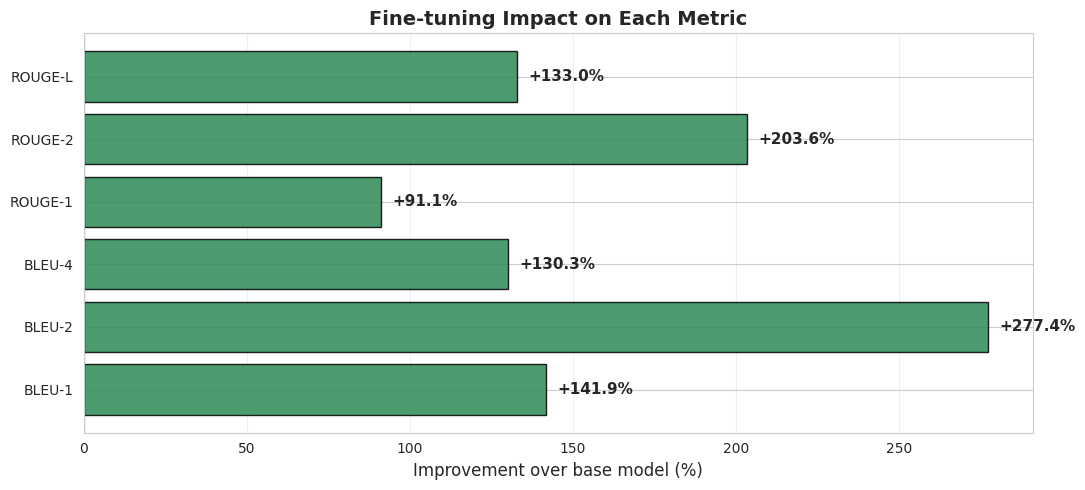

In [21]:
# ── Cell D: Improvement percentage chart ──────────────────────────────────────
improvements = [((ft - b) / (b + 1e-9)) * 100 for b, ft in zip(base_scores, ft_scores)]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2E8B57' if i > 0 else '#C0392B' for i in improvements]
bars = ax.barh(metric_names, improvements, color=colors, edgecolor='black', alpha=0.85)

for bar, imp in zip(bars, improvements):
    width = bar.get_width()
    ax.annotate(f'{imp:+.1f}%',
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(8 if width > 0 else -8, 0),
                textcoords='offset points',
                ha='left' if width > 0 else 'right',
                va='center', fontsize=11, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Improvement over base model (%)', fontsize=12)
ax.set_title('Fine-tuning Impact on Each Metric', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('improvement_chart.png', bbox_inches='tight')
plt.show()

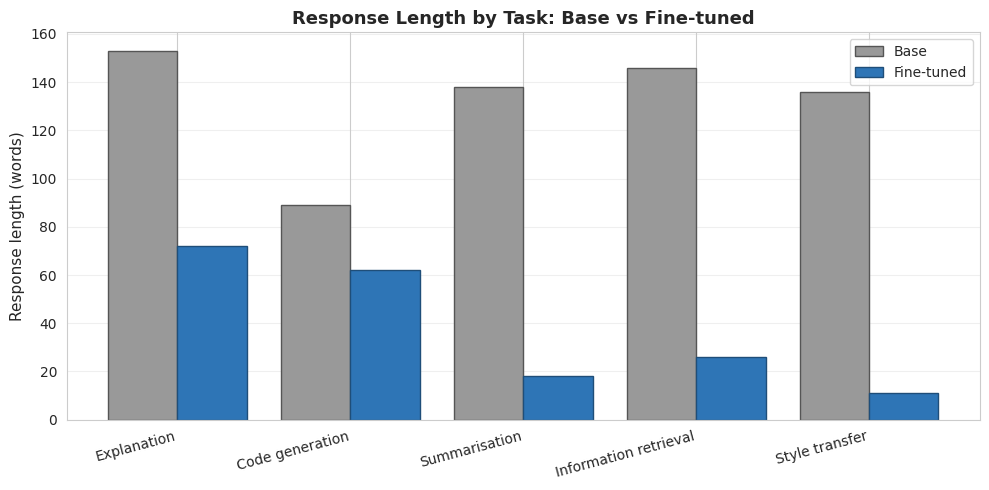

In [23]:
# ── Cell F: Side-by-side response comparison heatmap ──────────────────────────
import textwrap

# Build a per-prompt comparison from the qualitative test outputs
# (Re-uses the prompts from Cell 11)
comparison_data = []
for i, p in enumerate(prompts, 1):
    base_resp = generate(base_compare, p["instruction"], p["context"])
    ft_resp   = generate(ft_model,    p["instruction"], p["context"])
    comparison_data.append({
        'task': p['label'],
        'base_len': len(base_resp.split()),
        'ft_len': len(ft_resp.split()),
    })

df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df))
ax.bar(x - 0.2, df['base_len'], 0.4, label='Base', color='#999999', edgecolor='#555')
ax.bar(x + 0.2, df['ft_len'],   0.4, label='Fine-tuned', color='#2E75B6', edgecolor='#1F4E79')
ax.set_xticks(x)
ax.set_xticklabels(df['task'], rotation=15, ha='right')
ax.set_ylabel('Response length (words)', fontsize=11)
ax.set_title('Response Length by Task: Base vs Fine-tuned', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('response_lengths.png', bbox_inches='tight')
plt.show()

---
## Assignment complete

| Task | Cell |
|------|------|
| 1 — Load Mistral-7B in 4-bit QLoRA | Cell 5 |
| 2 — Fine-tune with LoRA on Dolly-15k | Cell 8 |
| 3 — Base vs fine-tuned comparison | Cell 11 |
| 4 — BLEU & ROUGE evaluation | Cell 12 |
